In [1]:
import sys
from pathlib import Path
import numpy as np
import torch
from torch_geometric.data import HeteroData
import random

root = Path().resolve()
if not (root / "src").exists():
    root = root.parent

sys.path.append(str(root))

from src.data.generators import generate_uncap_instance
from src.data.data import UncapGeneratorConfig, NormalConfig, UniformConfig, ConstantConfig
from src.data.prepare_data import GenerateDataset
from src.traces.uncap import solve_uncap_jv
from src.solvers.uncap_exact import solve_uncap_exact, solve_dual_exact
from src.utils.collate_fn import collate_fn, test_collate_fn

/home/simon/repos/FLP-NAR/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#SEED = 44
SEED = 33

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
gen_config = UncapGeneratorConfig(
    n_fac=10,
    n_cli=10,
    seed=33,
    demand_config=UniformConfig(0,1), #"normalized"
    facility_cost_config=UniformConfig(0,1), #"normalized"
    coords_config=NormalConfig(mean=0.5, std=0.5)
)

In [4]:
from torch.utils.data import DataLoader, ConcatDataset
import importlib
import src.models.reasoners
importlib.reload(src.models.reasoners)
from src.models.reasoners import Reasoner

TRAIN_CONFIGS = [
    {"n_fac": 10, "n_cli": 5, "n_samples": 500},
    {"n_fac": 5, "n_cli": 10, "n_samples": 500},
    {"n_fac": 10, "n_cli": 10, "n_samples": 2000},
]

train_datasets, val_datasets = [], []
for cfg in TRAIN_CONFIGS:
    gen_cfg = UncapGeneratorConfig(
        n_fac=cfg["n_fac"], n_cli=cfg["n_cli"], seed=33,
        demand_config=ConstantConfig(1),
        facility_cost_config=UniformConfig(0, 1),
        coords_config=NormalConfig(mean=0.5, std=0.5),
    )
    ds = GenerateDataset(gen_cfg, n_samples=cfg["n_samples"],
                         cache_dir=Path(f"data/train_{cfg['n_fac']}x{cfg['n_cli']}"))
    ds.prepare_data()
    n_train = int(0.75 * len(ds))
    n_val = len(ds) - n_train
    t, v = torch.utils.data.random_split(ds, [n_train, n_val])
    train_datasets.append(t)
    val_datasets.append(v)
    print(f"  {cfg['n_fac']}x{cfg['n_cli']}: {n_train} train / {n_val} val")

# Each scale gets its own loader (required by the reasoner — can't mix sizes in a batch)
BATCH_SIZE = 256
train_loaders = [
    DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
    for ds in train_datasets
]

VAL_CONFIGS = [
    {"n_fac": 10, "n_cli": 10, "n_samples": 200},
    {"n_fac": 15, "n_cli": 15, "n_samples": 100},
    {"n_fac": 20, "n_cli": 20, "n_samples": 50},
    {"n_fac": 30, "n_cli": 30, "n_samples": 30},
    {"n_fac": 100, "n_cli": 100, "n_samples": 15},
]
val_extra_loaders = {}
for cfg in VAL_CONFIGS:
    gen_cfg = UncapGeneratorConfig(
        n_fac=cfg["n_fac"], n_cli=cfg["n_cli"], seed=7777,
        demand_config=ConstantConfig(1),
        facility_cost_config=UniformConfig(0, 1),
        coords_config=NormalConfig(mean=0.5, std=0.5),
    )
    ds = GenerateDataset(gen_cfg, n_samples=cfg["n_samples"],
                         cache_dir=Path(f"data/val_{cfg['n_fac']}x{cfg['n_cli']}"))
    ds.prepare_data()
    loader = DataLoader(ds, batch_size=min(BATCH_SIZE, cfg["n_samples"]),
                        shuffle=False, collate_fn=collate_fn)
    key = f"{cfg['n_fac']}x{cfg['n_cli']}"
    val_extra_loaders[key] = loader
    print(f"  val scale {key}: {len(ds)} samples")

val_loaders_by_scale = {}
for i, cfg in enumerate(TRAIN_CONFIGS):
    key = f"{cfg['n_fac']}x{cfg['n_cli']}"
    val_loaders_by_scale[key] = DataLoader(
        val_datasets[i], batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn
    )
val_loaders_by_scale.update(val_extra_loaders)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Reasoner(hidden_dim=128, tf_prob=0.5).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

print(f"\ndevice : {device}")
print(f"params : {sum(p.numel() for p in model.parameters()):,}")
print(f"train loaders : {len(train_loaders)} scales")
print(f"val loaders   : {list(val_loaders_by_scale.keys())}")

loading instances from cache
  10x5: 375 train / 125 val
loading instances from cache
  5x10: 375 train / 125 val
loading instances from cache
  10x10: 1500 train / 500 val
loading instances from cache
  val scale 10x10: 200 samples
loading instances from cache
  val scale 15x15: 100 samples
loading instances from cache
  val scale 20x20: 50 samples
loading instances from cache
  val scale 30x30: 30 samples
loading instances from cache
  val scale 100x100: 15 samples


/home/simon/repos/FLP-NAR/src/models/processors.py:168: UserWarning: There exist node types ({'x'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  self.x_to_alpha = HeteroConv({
/home/simon/repos/FLP-NAR/src/models/processors.py:173: UserWarning: There exist node types ({'y', 'alpha'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  self.to_beta = HeteroConv({
/home/simon/repos/FLP-NAR/src/models/processors.py:185: UserWarning: There exist node types ({'alpha', 'beta'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  self.out = HeteroConv({



device : cuda
params : 660,494
train loaders : 3 scales
val loaders   : ['10x5', '5x10', '10x10', '15x15', '20x20', '30x30', '100x100']


In [ ]:
import os
from dataclasses import dataclass, field
from typing import Callable
from itertools import chain
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

@dataclass
class LossConfig:
    """Configuration for loss weights with optional scheduling."""
    weights: dict = field(default_factory=lambda: {
        "alpha_loss": 0.0, "beta_loss": 0.0, "x_loss": 0.0,
        "y_loss": 1.0, "delta_loss": 1.0, "x_res_loss": 1.0,
        "y_res_loss": 1.0, "optimum_loss": 0.1, "optimum_diff": 0.0, "dual_diff": 0.0,
    })
    schedulers: dict = field(default_factory=dict)

    def get_weights(self, epoch: int) -> dict:
        w = self.weights.copy()
        for k, scheduler in self.schedulers.items():
            if k in w:
                w[k] = scheduler(epoch)
        return w


class Trainer:
    """Training loop with multi-scale data, checkpointing, and plotting."""

    def __init__(self, model, optimizer, loss_config: LossConfig,
                 lr_scheduler=None, device="cuda",
                 checkpoint_dir: str = "checkpoints"):
        self.model = model
        self.optimizer = optimizer
        self.loss_config = loss_config
        self.lr_scheduler = lr_scheduler
        self.device = device
        self.checkpoint_dir = checkpoint_dir
        os.makedirs(checkpoint_dir, exist_ok=True)

        self.history = {
            "train": [],
            "val": {},
        }
        self.best_val_loss = float("inf")

    def save_checkpoint(self, path: str, epoch: int, val_loss: float):
        torch.save({
            "epoch": epoch,
            "model_state_dict": self.model.state_dict(),
            "optimizer_state_dict": self.optimizer.state_dict(),
            "lr_scheduler_state_dict": self.lr_scheduler.state_dict() if self.lr_scheduler else None,
            "val_loss": val_loss,
            "history": self.history,
            "loss_config": self.loss_config.weights,
        }, path)

    def load_checkpoint(self, path: str):
        ckpt = torch.load(path, map_location=self.device, weights_only=False)
        self.model.load_state_dict(ckpt["model_state_dict"])
        self.optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        if self.lr_scheduler and ckpt["lr_scheduler_state_dict"]:
            self.lr_scheduler.load_state_dict(ckpt["lr_scheduler_state_dict"])
        self.history = ckpt.get("history", self.history)
        self.best_val_loss = ckpt.get("val_loss", float("inf"))
        print(f"Loaded checkpoint from epoch {ckpt['epoch']} (val_loss={ckpt['val_loss']:.4f})")
        return ckpt["epoch"]

    @staticmethod
    def load_model(model, path: str, device="cuda"):
        """Load only the model weights (for inference)."""
        ckpt = torch.load(path, map_location=device, weights_only=False)
        model.load_state_dict(ckpt["model_state_dict"])
        print(f"Loaded model from epoch {ckpt['epoch']} (val_loss={ckpt['val_loss']:.4f})")
        return model

    def _run_epoch(self, loader, weights: dict, train: bool) -> dict:
        self.model.train(train)
        totals = {k: 0.0 for k in weights}
        n_batches = 0

        with torch.set_grad_enabled(train):
            for batch in loader:
                batch = batch.to(self.device)
                losses = self.model.teacher_forcing(batch)
                total = sum(weights[k] * losses[k] for k in weights)

                if train:
                    self.optimizer.zero_grad()
                    total.backward()
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
                    self.optimizer.step()

                for k in weights:
                    totals[k] += losses[k].item()
                n_batches += 1

        return {k: v / max(n_batches, 1) for k, v in totals.items()}

    def _weighted_total(self, losses: dict, weights: dict) -> float:
        return sum(weights.get(k, 0) * losses.get(k, 0) for k in weights)

    def fit(self, train_loaders: list, val_loaders: dict,
            n_epochs: int, verbose: bool = True):
        """
        Args:
            train_loaders: list of DataLoaders (one per scale)
            val_loaders:   dict[scale_key -> DataLoader]
            n_epochs:      number of epochs
        """
        for key in val_loaders:
            if key not in self.history["val"]:
                self.history["val"][key] = []

        pbar = tqdm(range(1, n_epochs + 1), desc="Training", disable=not verbose)
        for epoch in pbar:
            weights = self.loss_config.get_weights(epoch)
            self.model.tf_prob = max(((n_epochs - 150) - epoch) / max(n_epochs - 150, 1), 0.0)

            all_train_losses = []
            for loader in train_loaders:
                losses = self._run_epoch(loader, weights, train=True)
                all_train_losses.append(losses)

            train_avg = {k: sum(l[k] for l in all_train_losses) / len(all_train_losses)
                         for k in weights}
            train_avg["_weights"] = weights.copy()
            self.history["train"].append(train_avg)

            val_parts = []
            for key, loader in val_loaders.items():
                vl = self._run_epoch(loader, weights, train=False)
                self.history["val"][key].append(vl)
                val_parts.append(vl)

            val_avg = {k: sum(v[k] for v in val_parts) / len(val_parts) for k in weights}

            val_total = self._weighted_total(val_avg, weights)
            if val_total < self.best_val_loss:
                self.best_val_loss = val_total
                self.save_checkpoint(
                    os.path.join(self.checkpoint_dir, "best_model.pt"),
                    epoch, val_total,
                )

            if self.lr_scheduler:
                if isinstance(self.lr_scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                    self.lr_scheduler.step(val_total)
                else:
                    self.lr_scheduler.step()

            if verbose:
                train_total = self._weighted_total(train_avg, weights)
                lr = self.optimizer.param_groups[0]['lr']
                pbar.set_postfix_str(
                    f"lr={lr:.1e} "
                    f"t_loss={train_total:.3f} v_loss={val_total:.3f} "
                    f"t_opt={train_avg['optimum_diff']:.3f} "
                    f"v_opt={val_avg['optimum_diff']:.3f} "
                    f"t_dual={train_avg['dual_diff']:.3f} "
                    f"v_dual={val_avg['dual_diff']:.3f}"
                )

        self.save_checkpoint(
            os.path.join(self.checkpoint_dir, "last_model.pt"),
            n_epochs, val_total,
        )
        print(f"\nBest val loss: {self.best_val_loss:.4f}")
        return self.history

    def plot_history(self, weights: dict = None):
        """Plot training curves: losses + optimum/dual ratios per val scale."""
        if weights is None:
            weights = self.loss_config.weights

        epochs = range(1, len(self.history["train"]) + 1)
        train_h = self.history["train"]
        val_h = self.history["val"]

        loss_keys = [k for k in weights if k not in ("optimum_diff", "dual_diff")
                     and weights.get(k, 0) > 0]
        ratio_keys = ["optimum_diff", "dual_diff"]

        n_loss = len(loss_keys)
        n_ratio = len(ratio_keys)
        fig, axes = plt.subplots(1, n_loss + n_ratio, figsize=(5 * (n_loss + n_ratio), 4))
        if n_loss + n_ratio == 1:
            axes = [axes]

        for ax, key in zip(axes[:n_loss], loss_keys):
            ax.plot(epochs, [e[key] for e in train_h], label="train", linewidth=1.5)
            for vk, vh in val_h.items():
                ax.plot(epochs, [e[key] for e in vh], label=f"val {vk}", linewidth=1, alpha=0.8)
            ax.set(xlabel="Epoch", ylabel=key, title=key)
            ax.legend(fontsize=7)
            ax.grid(True, alpha=0.3)

        for ax, key in zip(axes[n_loss:], ratio_keys):
            ax.plot(epochs, [e[key] for e in train_h], label="train", linewidth=1.5)
            for vk, vh in val_h.items():
                ax.plot(epochs, [e[key] for e in vh], label=f"val {vk}", linewidth=1, alpha=0.8)
            ax.axhline(1.0, color="green", ls="--", alpha=0.5, label="optimal")
            ax.set(xlabel="Epoch", ylabel=key, title=key)
            ax.legend(fontsize=7)
            ax.grid(True, alpha=0.3)

        fig2, ax2 = plt.subplots(figsize=(8, 4))
        train_total = [
            self._weighted_total(e, e.get("_weights", weights))
            for e in train_h
        ]
        ax2.plot(epochs, train_total, label="train total", linewidth=1.5)
        for vk, vh in val_h.items():
            vt = [
                self._weighted_total(e, train_h[i].get("_weights", weights))
                for i, e in enumerate(vh)
            ]
            ax2.plot(epochs, vt, label=f"val {vk}", linewidth=1, alpha=0.8)
        ax2.set(xlabel="Epoch", ylabel="Weighted Loss", title="Total Weighted Loss")
        ax2.legend(fontsize=8)
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

def ramp_down(max_epoch=50):
    def fn(e):
        return max((max_epoch - e) / max_epoch, 0.2)
    return fn

def delayed_ramp(delay=10, max_epoch=50):
    def fn(e):
        return 0.1 * min(max((e - delay) / max_epoch, 0.0), 1.0)
    return fn

def limited_ramp_down(max_epoch=50):
    def fn(e):
        return max((max_epoch - e) / max_epoch, 0.5)
    return fn

loss_config = LossConfig(
    weights={
        "alpha_loss": 0.5, "beta_loss": 0.5, "x_loss": 0.5,
        "y_loss": 0.5, "delta_loss": 1.0, "x_res_loss": 2.0,
        "y_res_loss": 2.0, "optimum_loss": 0., "optimum_diff": 0.0, "dual_diff": 0.0,
    },
    schedulers={
        "alpha_loss": ramp_down(150),
        "beta_loss": ramp_down(150),
        "x_loss": ramp_down(150),
        "y_loss": ramp_down(150),
        "delta_loss": ramp_down(150),
        #"optimum_loss": delayed_ramp(0, 50),
        "x_res_loss": ramp_down(150),
        "y_res_loss": ramp_down(150),
    },
)

model.processor.processor.mixing = False

lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=1e-7)

trainer = Trainer(model, optimizer, loss_config, lr_scheduler, device,
                  checkpoint_dir="checkpoints")

N_EPOCHS = 200
history = trainer.fit(train_loaders, val_loaders_by_scale, N_EPOCHS)

trainer.plot_history()

Training:   6%|▋         | 13/200 [03:04<44:07, 14.16s/it, lr=9.5e-05 t_loss=0.725 v_loss=1.164 t_opt=1.307 v_opt=3.709 t_dual=1.254 v_dual=3.532]


KeyboardInterrupt: 

In [ ]:

def create_test_datasets(sizes: list[tuple[int, int]], n_samples: int = 100, base_seed: int = 9999):
    """
    Create test datasets of varying sizes.
    
    Args:
        sizes: List of (n_fac, n_cli) tuples
        n_samples: Number of samples per size
        base_seed: Base seed (offset by size index for reproducibility)
    
    Returns:
        Dict mapping size tuple to (dataset, dataloader)
    """
    test_datasets = {}
    
    for i, (n_fac, n_cli) in enumerate(sizes):
        print(f"Generating test set: n_fac={n_fac}, n_cli={n_cli}...")
        
        config = UncapGeneratorConfig(
            n_fac=n_fac,
            n_cli=n_cli,
            seed=base_seed + i * 1000,
            #demand_config=UniformConfig(0, 1),
            demand_config=ConstantConfig(1),
            facility_cost_config=UniformConfig(0, 1),
            coords_config=NormalConfig(mean=0.5, std=0.5)
        )
        
        dataset = GenerateDataset(
            config, 
            n_samples=n_samples, 
            cache_dir=Path(f"data/test_{n_fac}x{n_cli}"),
        )
        dataset.prepare_test_data()
        
        loader = DataLoader(
            dataset, 
            batch_size=1,
            shuffle=False, 
            collate_fn=test_collate_fn
        )
        
        test_datasets[(n_fac, n_cli)] = {"dataset": dataset, "loader": loader}
    
    return test_datasets


TEST_SIZES = [
    (5, 5),
    (10, 10),
    (15, 15),
    (20, 20),
    (10, 20),
    (20, 10),
]

In [ ]:
test_datasets = create_test_datasets(TEST_SIZES, n_samples=50)
scale_datasets = create_test_datasets([(30,30), (50,50), (100,100), (200,200)], n_samples=20)
hyper_scale_datasets = create_test_datasets([(300,300), (400,400)], n_samples=5)
test_datasets.update(scale_datasets)
test_datasets.update(hyper_scale_datasets)
test_datasets.update(create_test_datasets([(500,500)], n_samples=2))

Generating test set: n_fac=5, n_cli=5...
loading instances from cache
Generating test set: n_fac=10, n_cli=10...
loading instances from cache
Generating test set: n_fac=15, n_cli=15...
loading instances from cache
Generating test set: n_fac=20, n_cli=20...
loading instances from cache
Generating test set: n_fac=10, n_cli=20...
loading instances from cache
Generating test set: n_fac=20, n_cli=10...
loading instances from cache
Generating test set: n_fac=30, n_cli=30...
loading instances from cache
Generating test set: n_fac=50, n_cli=50...
loading instances from cache
Generating test set: n_fac=100, n_cli=100...
loading instances from cache
Generating test set: n_fac=200, n_cli=200...
loading instances from cache
Generating test set: n_fac=300, n_cli=300...
loading instances from cache
Generating test set: n_fac=400, n_cli=400...
loading instances from cache
Generating test set: n_fac=500, n_cli=500...
loading instances from cache


Loaded checkpoint from epoch 179 (val_loss=0.2024)
Evaluating 5x5...
Evaluating 10x10...
Evaluating 15x15...
Evaluating 20x20...
Evaluating 10x20...
Evaluating 20x10...
Evaluating 30x30...
Evaluating 50x50...
Evaluating 100x100...
Evaluating 200x200...
Evaluating 300x300...
Evaluating 400x400...
Evaluating 500x500...
         opt_ratio_mean  opt_ratio_std  gap_pct_mean  gap_pct_median  \
size                                                                   
100x100          1.1465         0.0510       14.6492         14.0294   
10x10            1.0957         0.0947        9.5739          5.5871   
10x20            1.0527         0.0494        5.2691          3.8625   
15x15            1.0692         0.0644        6.9197          5.0655   
200x200          1.1454         0.0463       14.5424         13.6487   
20x10            1.0930         0.0813        9.2992          8.1563   
20x20            1.0856         0.0659        8.5623          7.1954   
300x300          1.1585         0

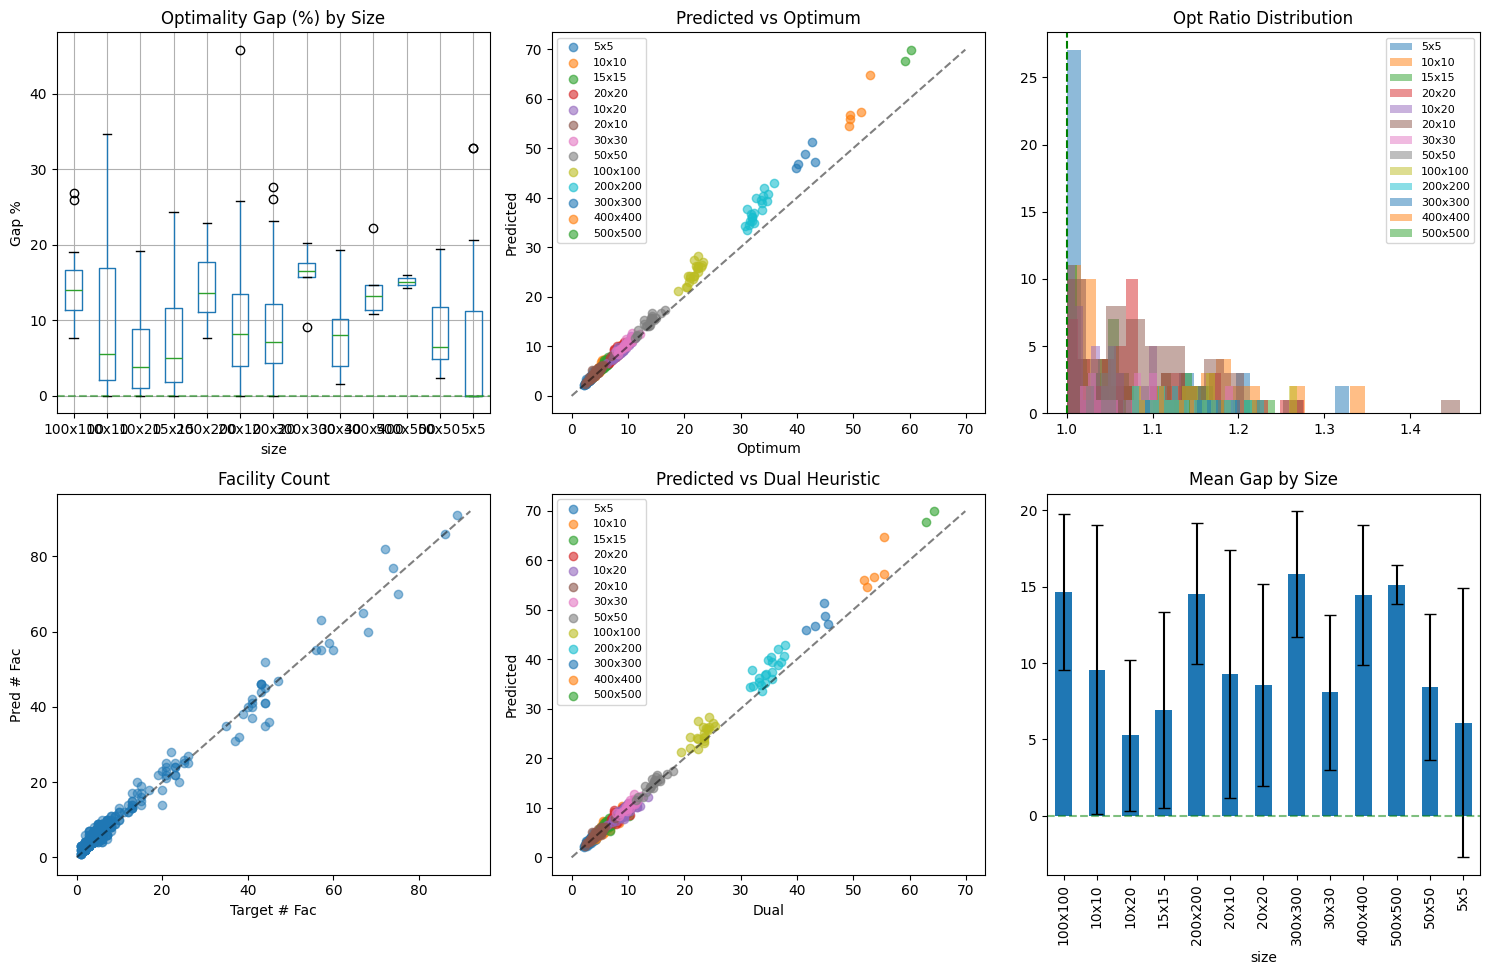

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import importlib, src.models.reasoners
importlib.reload(src.models.reasoners)
from src.models.reasoners import Reasoner

trainer.load_checkpoint("checkpoints/best_model.pt")

all_results = []
for (nf, nc), data in test_datasets.items():
    print(f"Evaluating {nf}x{nc}...")
    for batch in data["loader"]:
        batch = batch.to(device)
        all_results.extend(model.inference(batch, repair=True))

df = pd.DataFrame([
    {
        "size": f"{r['n_fac']}x{r['n_cli']}",
        "n_fac": r["n_fac"],
        "n_cli": r["n_cli"],
        "predicted": r["pred_cost"],
        "optimum": r["optimum"],
        "dual_bound": r["dual_bound"],
        "opt_ratio": r["opt_ratio"],
        "dual_ratio": r["dual_ratio"],
        "opt_gap_pct": (r["opt_ratio"] - 1.0) * 100,
        "n_fac_opened": int(r["repaired_opened"].sum()),
        "n_fac_target": int((r["y_target"] > 0.5).sum()),
    }
    for r in all_results
])

print(df.groupby("size").agg(
    opt_ratio_mean=("opt_ratio", "mean"),
    opt_ratio_std=("opt_ratio", "std"),
    gap_pct_mean=("opt_gap_pct", "mean"),
    gap_pct_median=("opt_gap_pct", "median"),
    fac_opened_mean=("n_fac_opened", "mean"),
    fac_target_mean=("n_fac_target", "mean"),
    count=("opt_ratio", "count"),
).round(4))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

df.boxplot(column="opt_gap_pct", by="size", ax=axes[0, 0])
axes[0, 0].set_title("Optimality Gap (%) by Size"); axes[0, 0].set_ylabel("Gap %")
axes[0, 0].axhline(0, color="g", ls="--", alpha=.5); plt.suptitle("")

for s in df["size"].unique():
    sub = df[df["size"] == s]
    axes[0, 1].scatter(sub["optimum"], sub["predicted"], label=s, alpha=.6)
mx = max(df["optimum"].max(), df["predicted"].max())
axes[0, 1].plot([0, mx], [0, mx], "k--", alpha=.5)
axes[0, 1].set(xlabel="Optimum", ylabel="Predicted", title="Predicted vs Optimum")
axes[0, 1].legend(fontsize=8)

for s in df["size"].unique():
    axes[0, 2].hist(df[df["size"] == s]["opt_ratio"], bins=20, alpha=.5, label=s)
axes[0, 2].axvline(1.0, color="g", ls="--"); axes[0, 2].set_title("Opt Ratio Distribution")
axes[0, 2].legend(fontsize=8)

axes[1, 0].scatter(df["n_fac_target"], df["n_fac_opened"], alpha=.5)
mf = max(df["n_fac_target"].max(), df["n_fac_opened"].max()) + 1
axes[1, 0].plot([0, mf], [0, mf], "k--", alpha=.5)
axes[1, 0].set(xlabel="Target # Fac", ylabel="Pred # Fac", title="Facility Count")

for s in df["size"].unique():
    sub = df[df["size"] == s]
    axes[1, 1].scatter(sub["dual_bound"], sub["predicted"], label=s, alpha=.6)
mx = max(df["dual_bound"].max(), df["predicted"].max())
axes[1, 1].plot([0, mx], [0, mx], "k--", alpha=.5)
axes[1, 1].set(xlabel="Dual", ylabel="Predicted", title="Predicted vs Dual Heuristic")
axes[1, 1].legend(fontsize=8)

summary = df.groupby("size")["opt_gap_pct"].agg(["mean", "std"])
summary.plot.bar(y="mean", yerr="std", ax=axes[1, 2], capsize=4, legend=False)
axes[1, 2].set_title("Mean Gap by Size"); axes[1, 2].axhline(0, color="g", ls="--", alpha=.5)

plt.tight_layout(); plt.show()

BEST predictions
  Gap: -0.00%  Pred: 4.0423  Opt: 4.0423


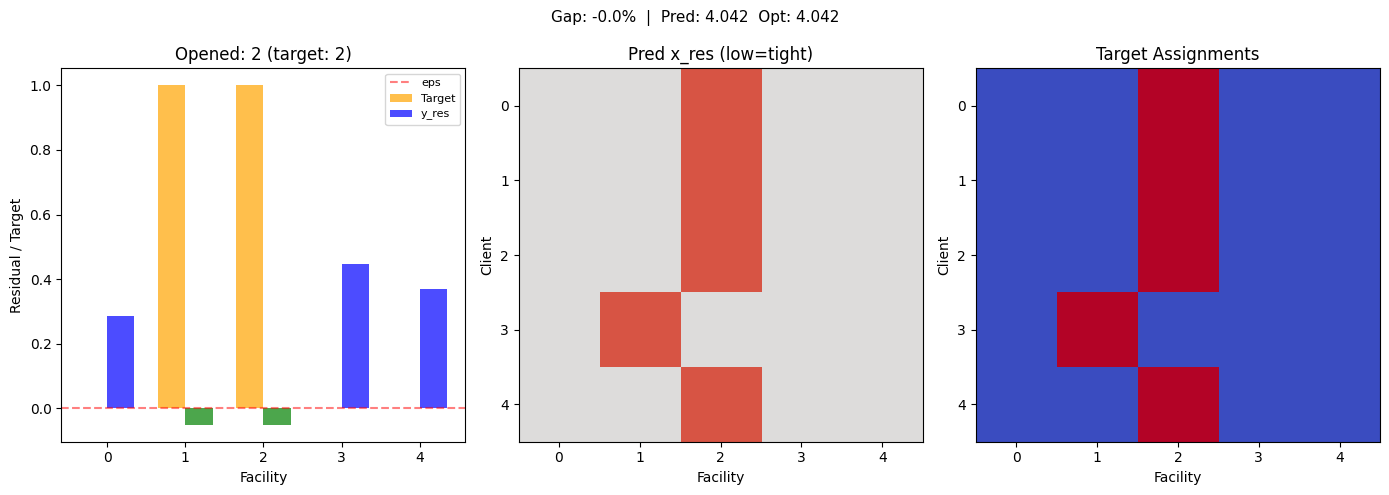

  Gap: -0.00%  Pred: 5.1519  Opt: 5.1519


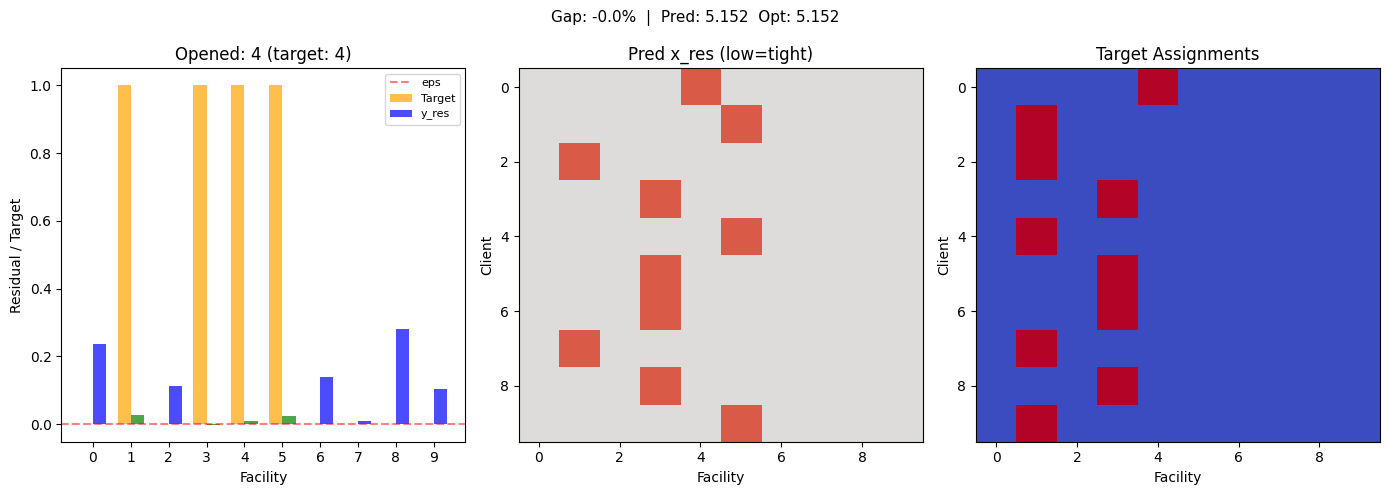

  Gap: -0.00%  Pred: 4.1574  Opt: 4.1574


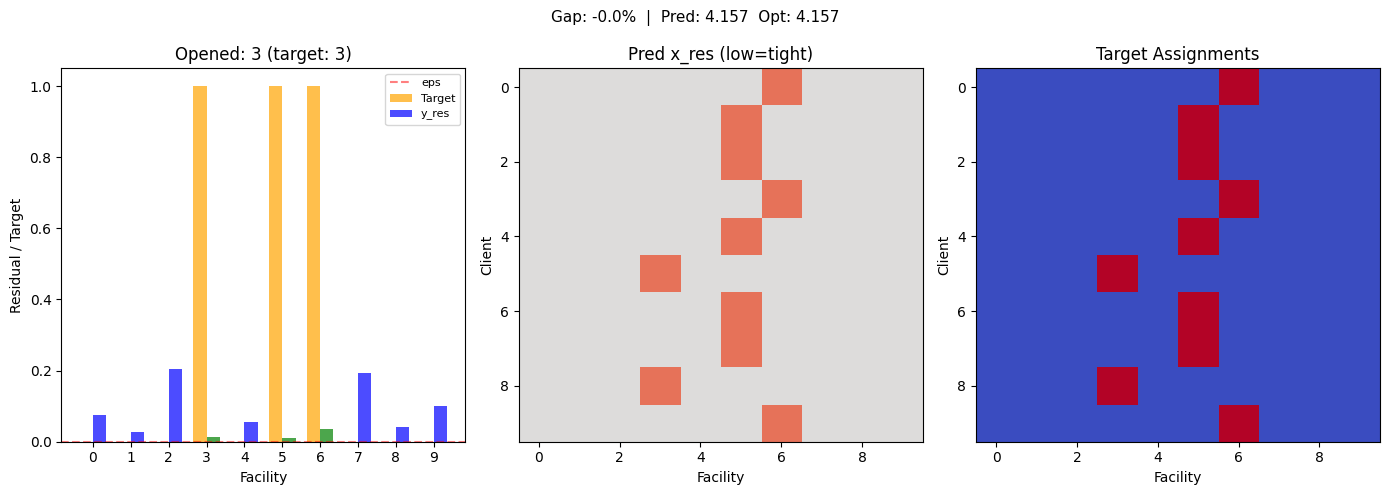

  Gap: -0.00%  Pred: 3.9565  Opt: 3.9565


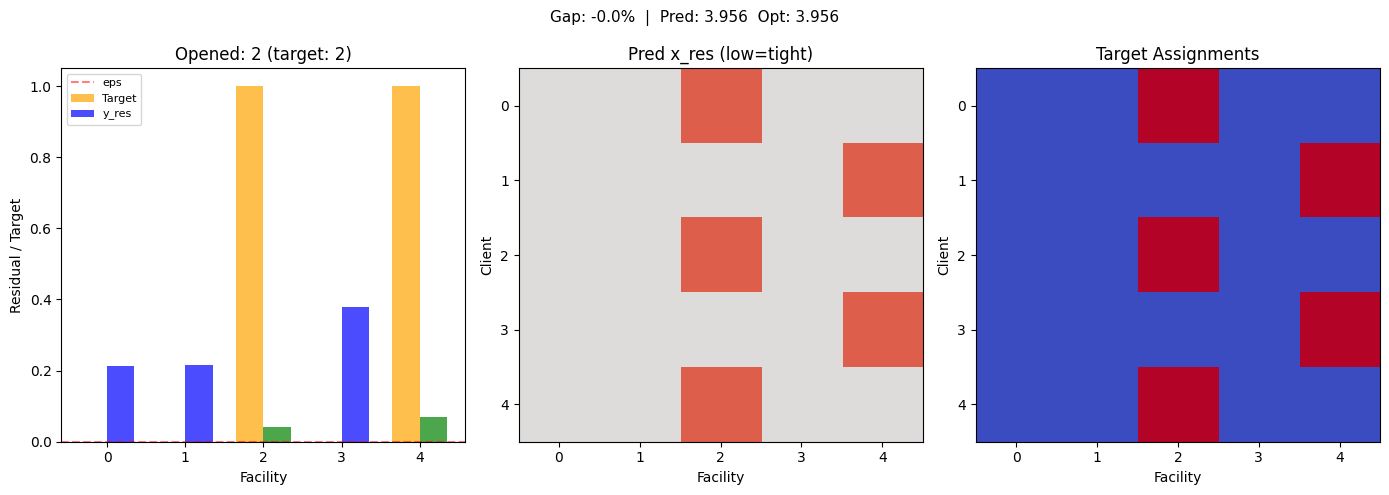

  Gap: -0.00%  Pred: 2.9784  Opt: 2.9784


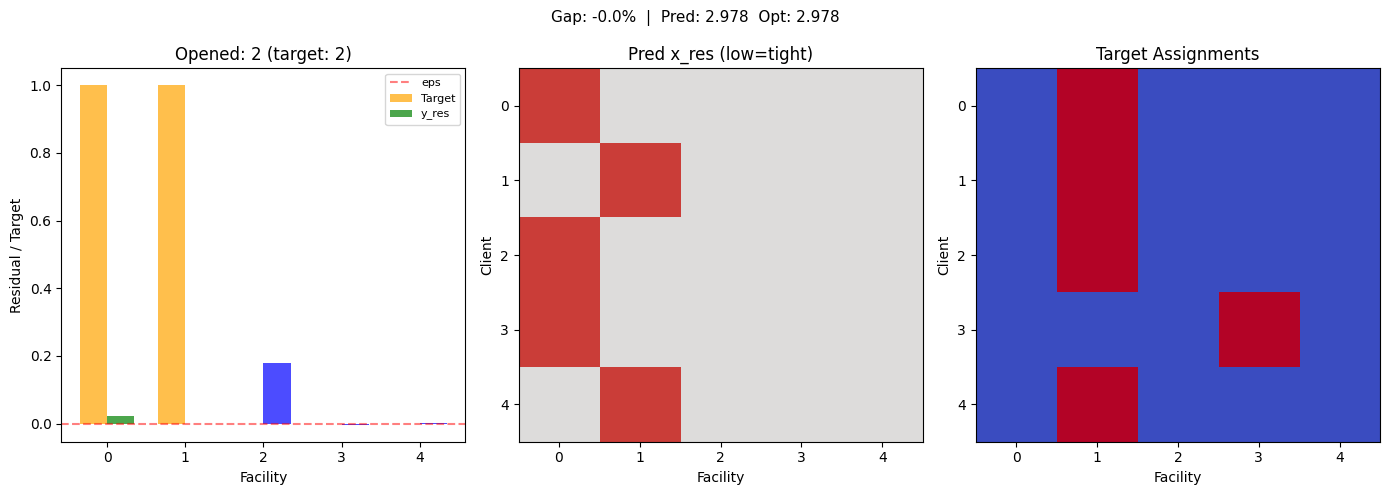

WORST predictions
  Gap: 32.77%  Pred: 3.3771  Opt: 2.5436


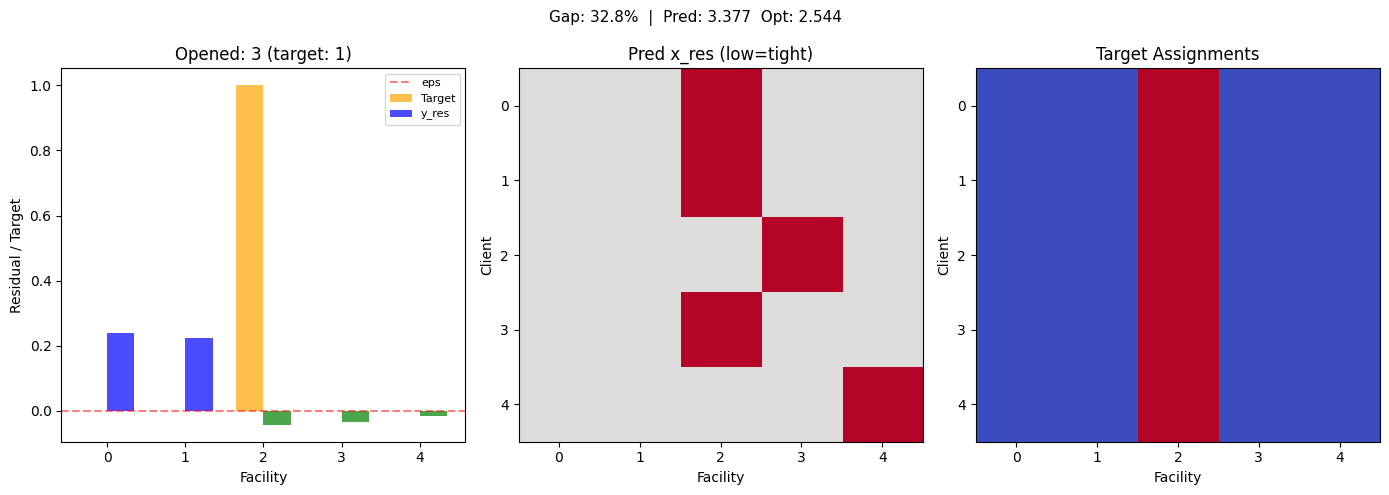

  Gap: 32.83%  Pred: 4.9404  Opt: 3.7194


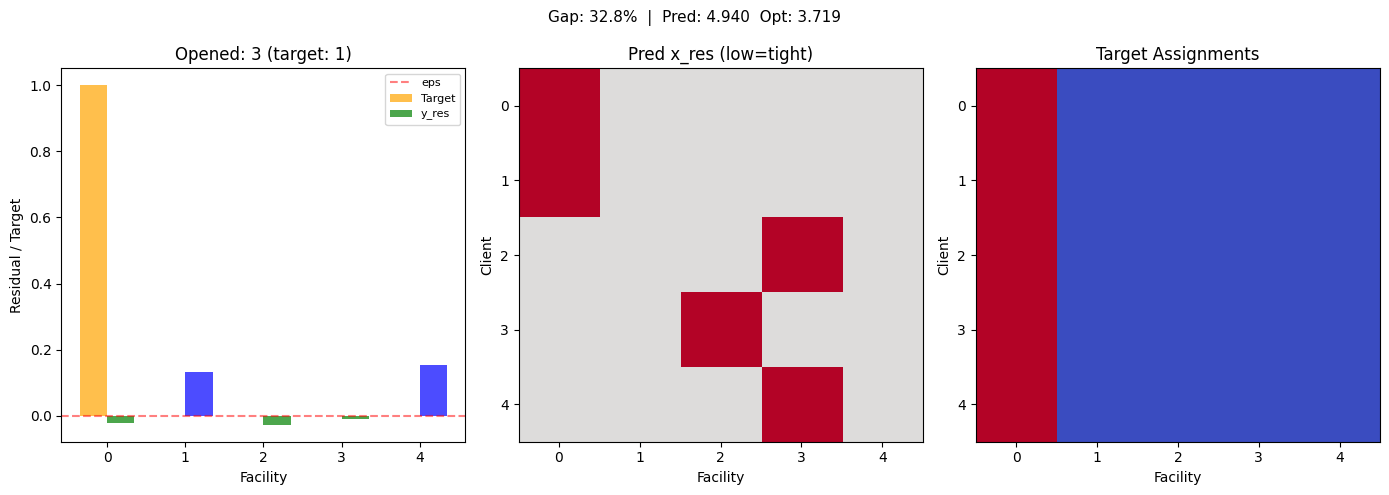

  Gap: 33.42%  Pred: 6.8577  Opt: 5.1399


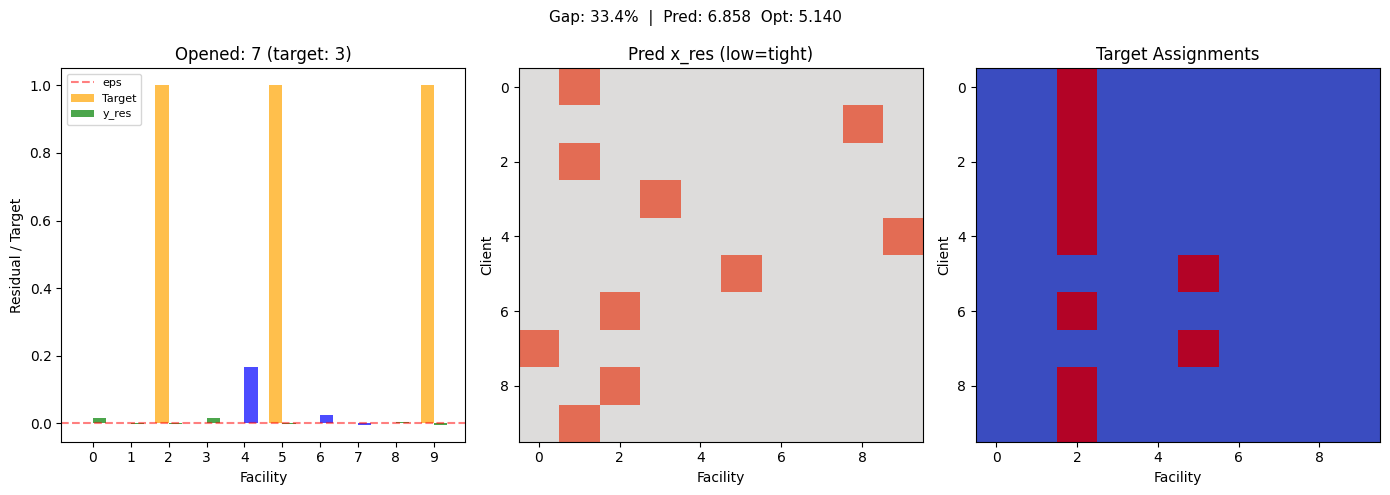

  Gap: 34.68%  Pred: 7.2826  Opt: 5.4073


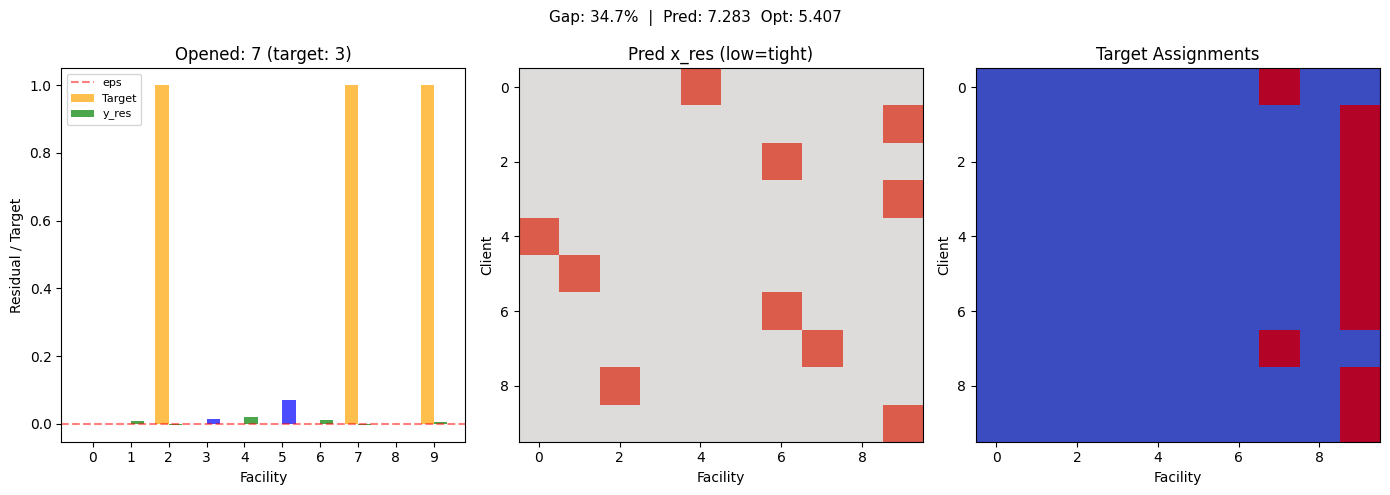

  Gap: 45.81%  Pred: 5.1952  Opt: 3.5629


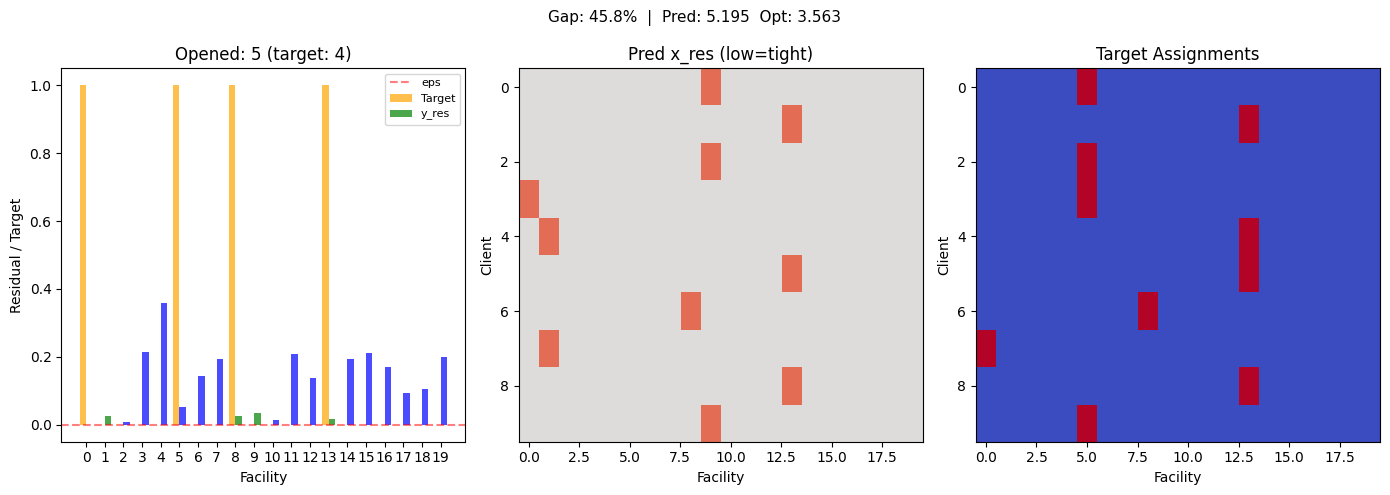

In [ ]:
from matplotlib.colors import TwoSlopeNorm

def inspect_solution(r, n_fac, n_cli, figsize=(14, 5)):
    fig, axes = plt.subplots(1, 3, figsize=figsize)

    # Facility residuals vs target
    ax = axes[0]
    x_pos = np.arange(n_fac); w = 0.35
    ax.bar(x_pos - w/2, r["y_target"][:n_fac], w, label="Target", alpha=.7, color="orange")
    colors = ["green" if o else "blue" for o in r["repaired_opened"][:n_fac]]
    ax.bar(x_pos + w/2, r["y_res"][:n_fac], w, label="y_res", alpha=.7, color=colors)
    ax.axhline(1e-8, color="r", ls="--", alpha=.5, label="eps")
    ax.set(xlabel="Facility", ylabel="Residual / Target")
    ax.set_title(f"Opened: {int(r['repaired_opened'].sum())} (target: {int((r['y_target']>.5).sum())})")
    ax.legend(fontsize=8); ax.set_xticks(x_pos)

    # x_res heatmap
    x_res_data = r["x_res"].reshape(n_cli, n_fac)
    vmin, vmax = float(x_res_data.min()), float(x_res_data.max())

    # If all values same sign, fall back to simple norm
    if vmin < 0 < vmax:
        norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
    elif vmin < 0:
        norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=max(vmax, 1e-8))
    else:
        norm = None  # all non-negative, default norm is fine
    axes[1].imshow(torch.nn.functional.one_hot(torch.from_numpy(r["assignment"][0]), num_classes=r["n_fac"]).numpy(), aspect="auto", cmap="coolwarm", norm=norm)
    axes[1].set(xlabel="Facility", ylabel="Client", title="Pred x_res (low=tight)")

    # Target assignments
    axes[2].imshow(torch.nn.functional.one_hot(torch.from_numpy(r["x_res_target"]), num_classes=r["n_fac"]).numpy(), aspect="auto", cmap="coolwarm")
    axes[2].set(xlabel="Facility", ylabel="Client", title="Target Assignments")

    gap = (r["opt_ratio"] - 1) * 100
    fig.suptitle(f"Gap: {gap:.1f}%  |  Pred: {r['pred_cost']:.3f}  Opt: {r['optimum']:.3f}", fontsize=11)
    plt.tight_layout(); plt.show()

N_INSPECT = 5
sorted_results = sorted(all_results, key=lambda r: r["opt_ratio"])

print("=" * 60, "\nBEST predictions\n", "=" * 60)
for r in sorted_results[:N_INSPECT]:
    print(f"  Gap: {(r['opt_ratio']-1)*100:.2f}%  Pred: {r['pred_cost']:.4f}  Opt: {r['optimum']:.4f}")
    inspect_solution(r, r["n_fac"], r["n_cli"])

print("=" * 60, "\nWORST predictions\n", "=" * 60)
for r in sorted_results[-N_INSPECT:]:
    print(f"  Gap: {(r['opt_ratio']-1)*100:.2f}%  Pred: {r['pred_cost']:.4f}  Opt: {r['optimum']:.4f}")
    inspect_solution(r, r["n_fac"], r["n_cli"])